# Question 4: Otsu Thresholding and Selective Histogram Equalization

Given the image of a woman standing in front of an open window:
- Convert to grayscale
- **(a)** Use **Otsu thresholding** to obtain a binary mask for the foreground (woman + room). Report the threshold value.
- **(b)** Apply **histogram equalization only to the foreground** region. Identify the hidden features revealed.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Load and Convert to Grayscale

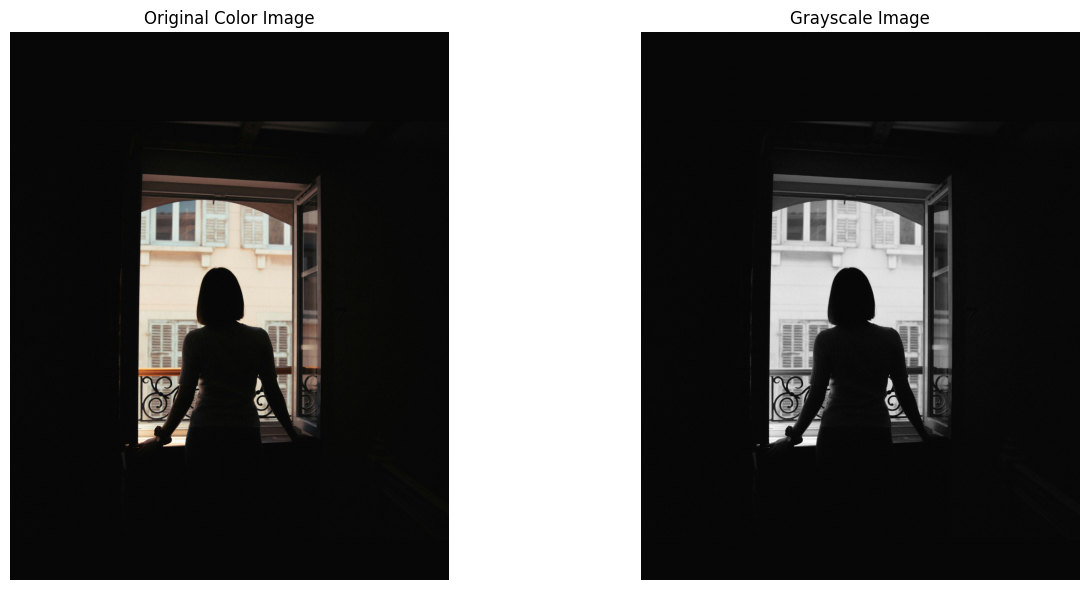

Image shape: (5867, 4693)


In [2]:
img_bgr = cv.imread('images/women-standing-open-door.jpg')
assert img_bgr is not None, "Could not load image. Check the images/ folder."

# Convert to grayscale
img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
axes[0].set_title('Original Color Image')
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Grayscale Image')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('output/q4_grayscale.png', dpi=150, bbox_inches='tight')
plt.show()
print('Image shape:', img_gray.shape)

## (a) Otsu Thresholding

**How Otsu works:**  
Otsu's method automatically finds the optimal threshold that **minimises the intra-class variance** (equivalently, maximises inter-class variance) between two classes — foreground and background. It works best when the histogram is **bimodal** (two distinct peaks), which is exactly the case here: the dark room interior vs the bright window exterior.

The foreground here is the **woman + the dark room** (everything that is NOT the bright exterior sky/building through the window).

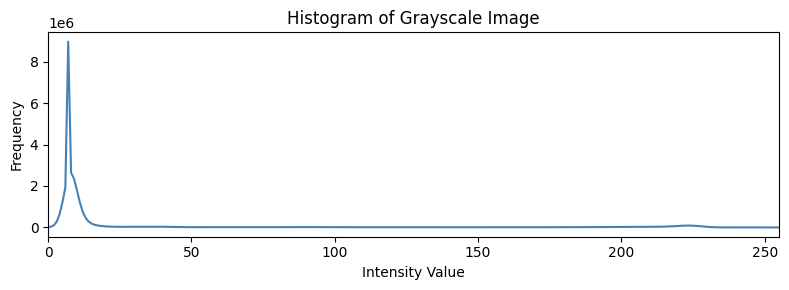

In [3]:
# Plot histogram first to visualise the bimodal distribution
hist, _ = np.histogram(img_gray.ravel(), 256, [0, 256])

plt.figure(figsize=(8, 3))
plt.plot(hist, color='steelblue')
plt.title('Histogram of Grayscale Image')
plt.xlabel('Intensity Value')
plt.ylabel('Frequency')
plt.xlim([0, 255])
plt.tight_layout()
plt.show()

Otsu threshold value: 101.0


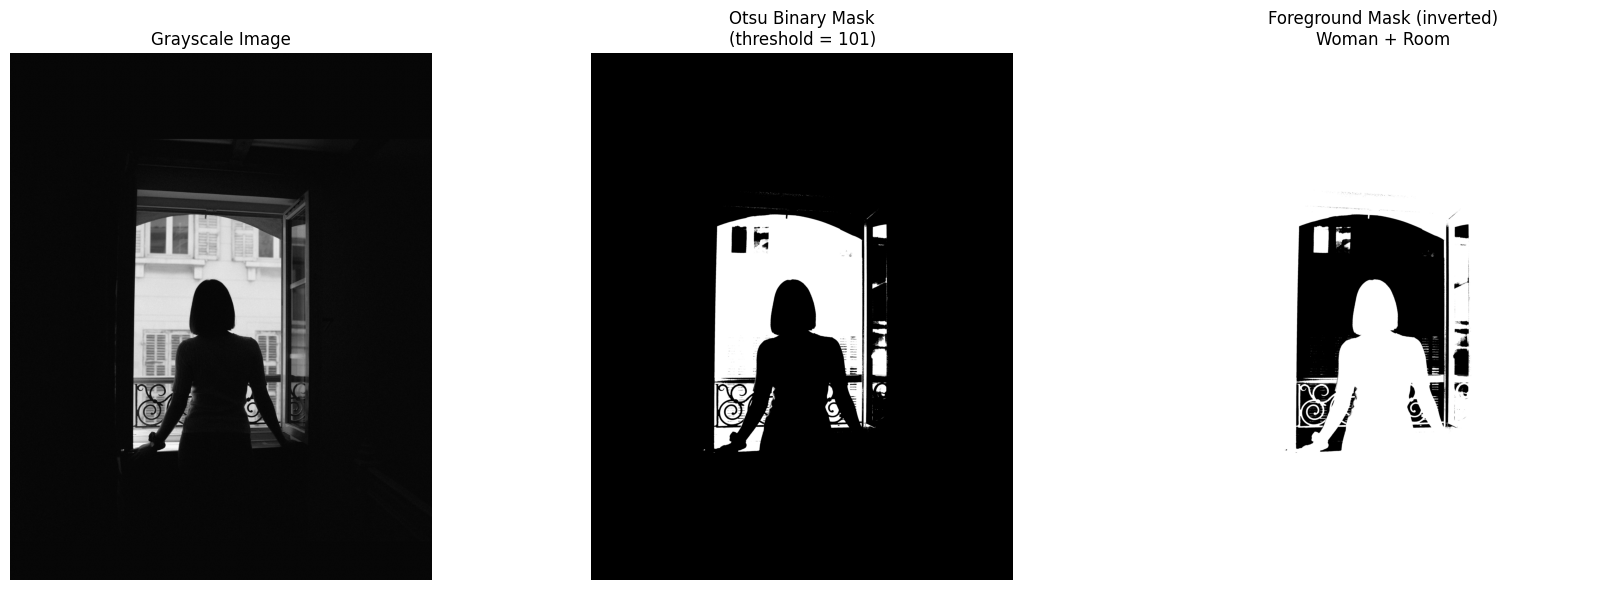

In [4]:
# Apply Otsu thresholding
# cv.THRESH_BINARY + cv.THRESH_OTSU: OpenCV automatically computes the optimal threshold
otsu_threshold, binary_mask = cv.threshold(
    img_gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU
)

print(f'Otsu threshold value: {otsu_threshold}')

# binary_mask: 255 = above threshold (bright exterior), 0 = below (dark foreground)
# We want the FOREGROUND mask (dark room + woman) so we INVERT it
foreground_mask = cv.bitwise_not(binary_mask)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Grayscale Image')
axes[0].axis('off')

axes[1].imshow(binary_mask, cmap='gray')
axes[1].set_title(f'Otsu Binary Mask\n(threshold = {int(otsu_threshold)})')
axes[1].axis('off')

axes[2].imshow(foreground_mask, cmap='gray')
axes[2].set_title('Foreground Mask (inverted)\nWoman + Room')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('output/q4a_otsu_mask.png', dpi=150, bbox_inches='tight')
plt.show()

## (b) Histogram Equalization on Foreground Only

We apply equalization **only to the pixels inside the foreground mask**, leaving the bright exterior unchanged.

In [5]:
def equalize_histogram(image):
    """
    Custom histogram equalization (same function from Q3).
    Works on a flat set of pixels — used here only on foreground pixels.
    """
    M, N = image.shape
    L = 256
    hist, _ = np.histogram(image.ravel(), bins=L, range=[0, 256])
    cdf = hist.cumsum()
    lut = np.array([(L - 1) / (M * N) * cdf[i] for i in range(L)], dtype=np.uint8)
    return lut[image], lut

Number of foreground pixels: 24982364


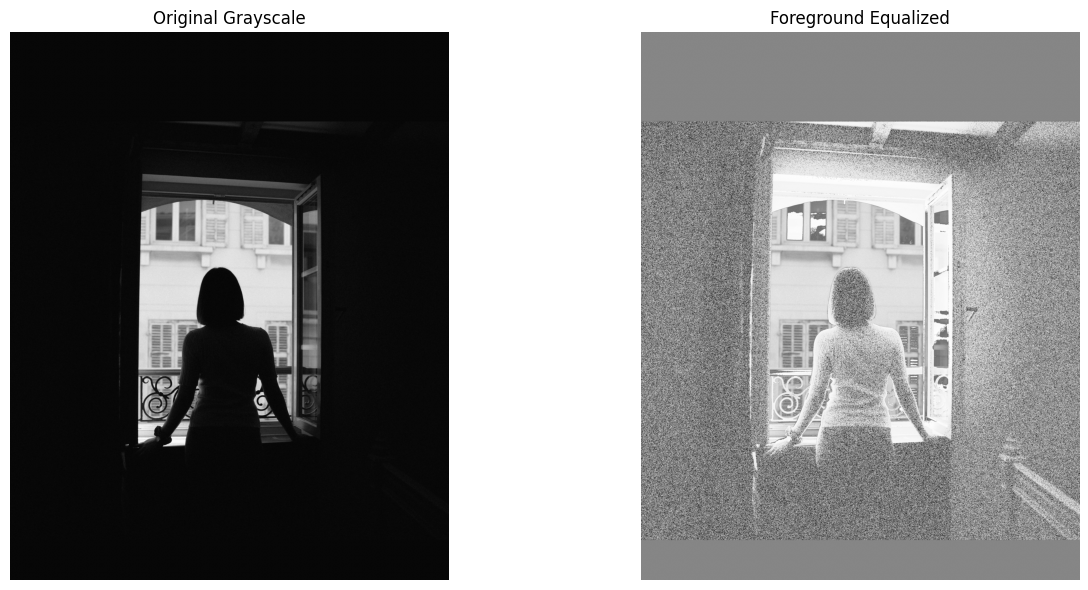

In [6]:
# Equalize only the foreground region

# Start with a copy of the grayscale image
img_eq = img_gray.copy()

# Extract foreground pixels using the mask
# foreground_mask == 255 where the dark room/woman is
fg_pixels = img_gray[foreground_mask == 255]
print(f'Number of foreground pixels: {fg_pixels.shape[0]}')

# Build equalization LUT from foreground pixels ONLY
L = 256
hist_fg, _ = np.histogram(fg_pixels, bins=L, range=[0, 256])
cdf_fg = hist_fg.cumsum()
n_fg = fg_pixels.shape[0]   # total foreground pixels
lut_fg = np.array([(L - 1) / n_fg * cdf_fg[i] for i in range(L)], dtype=np.uint8)

# Apply LUT only to foreground pixels in the output image
img_eq[foreground_mask == 255] = lut_fg[img_gray[foreground_mask == 255]]

# Display result
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(img_eq, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Foreground Equalized')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('output/q4b_foreground_equalized.png', dpi=150, bbox_inches='tight')
plt.show()

## Histograms — Before vs After (Foreground Only)

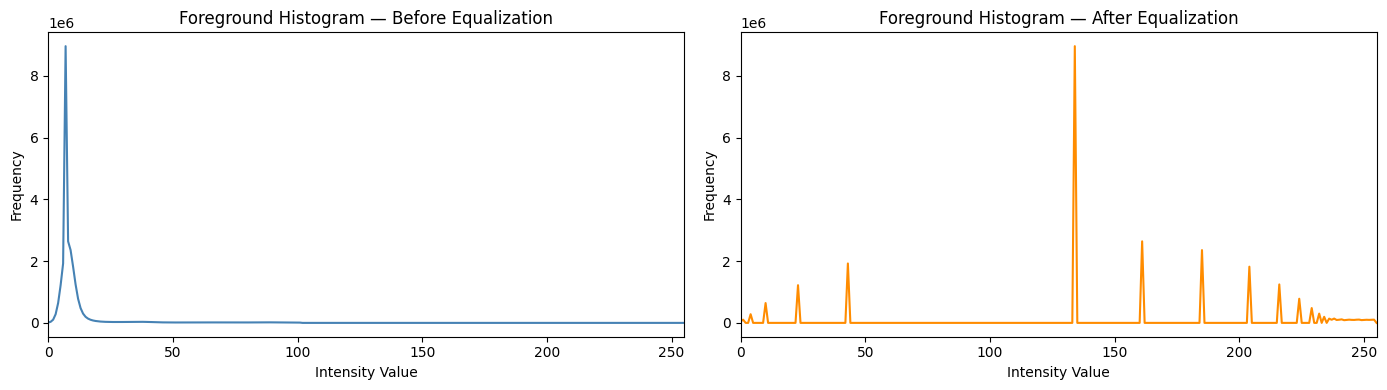

In [7]:
# Histogram of foreground pixels before and after equalization
fg_pixels_eq = img_eq[foreground_mask == 255]

hist_before, _ = np.histogram(fg_pixels,    256, [0, 256])
hist_after,  _ = np.histogram(fg_pixels_eq, 256, [0, 256])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_before, color='steelblue')
axes[0].set_title('Foreground Histogram — Before Equalization')
axes[0].set_xlabel('Intensity Value')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim([0, 255])

axes[1].plot(hist_after, color='darkorange')
axes[1].set_title('Foreground Histogram — After Equalization')
axes[1].set_xlabel('Intensity Value')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim([0, 255])

plt.tight_layout()
plt.savefig('output/q4b_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary — Full Comparison

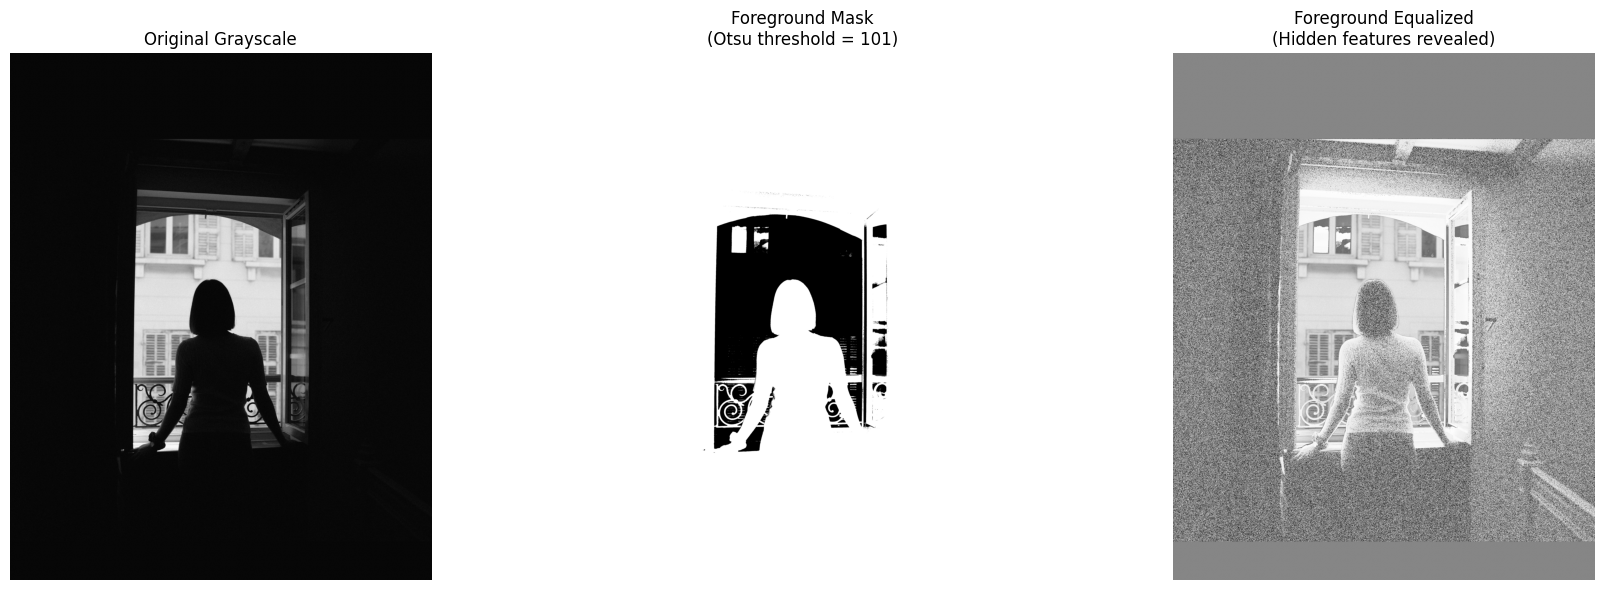

Otsu threshold value: 101

Hidden features revealed after equalization:
  - Texture and folds in the woman's clothing
  - Details of the decorative ironwork on the window frame
  - Contours of the door frame and room walls
  - Floor and furniture details in the dark room interior


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(foreground_mask, cmap='gray')
axes[1].set_title(f'Foreground Mask\n(Otsu threshold = {int(otsu_threshold)})')
axes[1].axis('off')

axes[2].imshow(img_eq, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Foreground Equalized\n(Hidden features revealed)')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('output/q4_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Otsu threshold value: {int(otsu_threshold)}')
print()
print('Hidden features revealed after equalization:')
print('  - Texture and folds in the woman\'s clothing')
print('  - Details of the decorative ironwork on the window frame')
print('  - Contours of the door frame and room walls')
print('  - Floor and furniture details in the dark room interior')